Task 6 K-Nearest Neighbors (KNN) Classification

 1.Choose a classification dataset and normalize features.

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv("Iris.csv")

# Drop Id column
df = df.drop('Id', axis=1)

# Separte features x and target y
x = df.drop('Species', axis=1)
y = df['Species']

# Encode the labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Normalize features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

 2.Use KNeighborsClassifier from sklearn.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Split into 70% train and 30% test
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_encoded, test_size=0.3, random_state=42)

# Train KNN with K=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

 3.Experiment with different values of K.

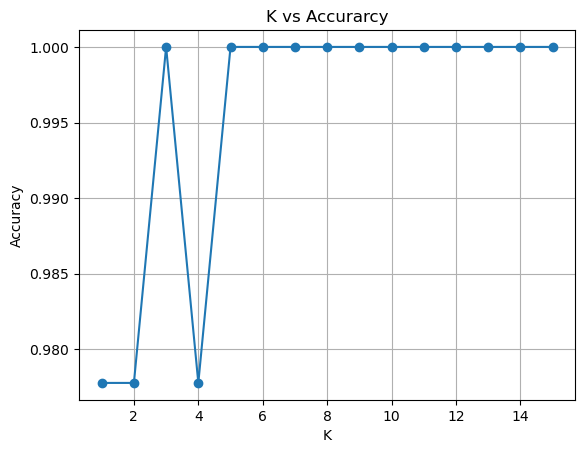

In [4]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_vals = list(range(1, 16))
accuraries = []

for k in k_vals:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    accuraries.append(accuracy_score(y_test, y_pred))
    
# Plot accuracy vs k
plt.plot(k_vals, accuraries, marker='o')    
plt.title("K vs Accurarcy")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

 4.Evaluate model using accuracy, confusion matrix.

Best K: 3
Accuraccy: 1.0


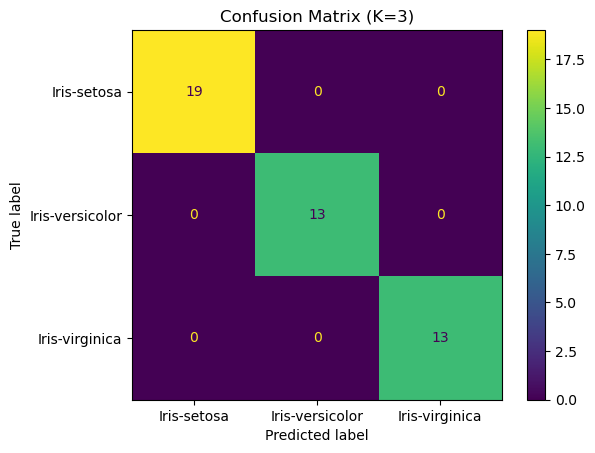

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Best K
best_k = k_vals[accuraries.index(max(accuraries))]
print("Best K:", best_k)

# Train the model
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(x_train, y_train)
y_pred = knn_best.predict(x_test)

# Accuracy
print("Accuraccy:", accuracy_score(y_test, y_pred))

# Confusion Maxtrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
plt.title(f"Confusion Matrix (K={best_k})")
plt.show()

 5.Visualize decision boundaries.

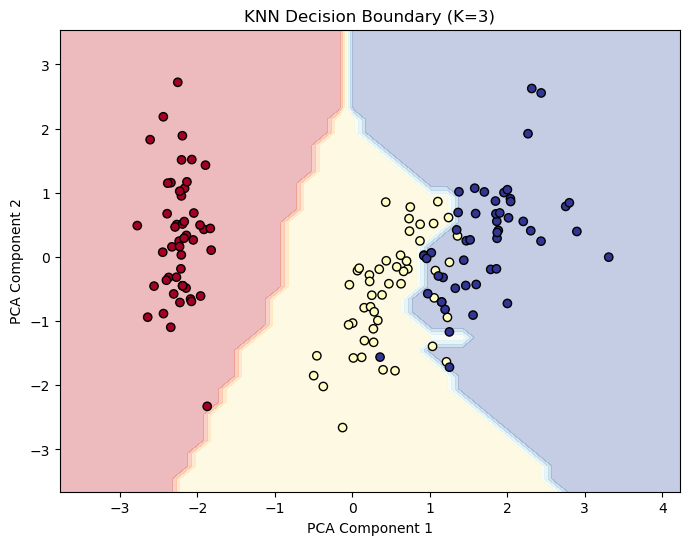

In [8]:
from sklearn.decomposition import PCA
import numpy as np
import numpy as pd

# Reduce to 2D for plotting
pca = PCA(n_components=2)
x_2d = pca.fit_transform(x_scaled)

# Split PCA-reduced data
x_train_2d, x_test_2d, y_train_2d, y_test_2d = train_test_split(x_2d, y_encoded, test_size=0.3, random_state=42)

# Train on 2D data
knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(x_train_2d, y_train_2d)

# Plotting function
def plot_decision_boundary(clf, x, y, title):
    h = 0.2
    x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(x[:, 0], x[:, 1], c=y, edgecolor='k', cmap=plt.cm.RdYlBu)
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

plot_decision_boundary(knn_2d, x_2d, y_encoded, f"KNN Decision Boundary (K={best_k})")